### Search the STAC catalog

Here we use (Earth Search)[https://element84.com/earth-search/] since it has Sentinel and Landsat, but could also use (CDSE API)[https://stac.dataspace.copernicus.eu/v1/]. That one needs registration and secret key.

Check first what collections are available.

In [1]:
import pystac_client
import odc.stac
from dask.distributed import Client

In [2]:
catalog = pystac_client.Client.open(
    "https://earth-search.aws.element84.com/v1"
)

# See what's on offer
for c in catalog.get_collections():
    print(c.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


Then make a specific search.

In [3]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=[-22.32, 63.85, -22.15, 63.95],
    datetime="2021-03-01/2023-10-15",
    query={"eo:cloud_cover": {"lt": 60}},
)
items = search.item_collection()
print(f"{len(items)} scenes found")

# drop useless winter months
items = [i for i in items if 3 <= i.datetime.month <= 10]
print(f"{len(items)} scenes after season filter")

216 scenes found
203 scenes after season filter


Check the data

In [4]:
item = items[0]
print(item.id)
print(item.datetime)
print(item.properties["eo:cloud_cover"])
print(list(item.assets.keys()))   # 'red', 'nir', 'scl', ... each is a URL to a COG
print(item.assets["red"].href)    # the actual file URL

S2B_27WVM_20231006_0_L2A
2023-10-06 13:03:58.100000+00:00
14.962779
['aot', 'blue', 'coastal', 'granule_metadata', 'green', 'nir', 'nir08', 'nir09', 'red', 'rededge1', 'rededge2', 'rededge3', 'scl', 'swir16', 'swir22', 'thumbnail', 'tileinfo_metadata', 'visual', 'wvp', 'aot-jp2', 'blue-jp2', 'coastal-jp2', 'green-jp2', 'nir-jp2', 'nir08-jp2', 'nir09-jp2', 'red-jp2', 'rededge1-jp2', 'rededge2-jp2', 'rededge3-jp2', 'scl-jp2', 'swir16-jp2', 'swir22-jp2', 'visual-jp2', 'wvp-jp2']
https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/27/W/VM/2023/10/S2B_27WVM_20231006_0_L2A/B04.tif


### Build the lazy cube

In [5]:
cube = odc.stac.load(
    items,
    bands=["red", "green", "blue", "nir", "swir16", "swir22", "scl"],
    crs="EPSG:32627",              # UTM 27N 
    resolution=10,                  # metres, because CRS is projected
    bbox=[-22.32, 63.85, -22.15, 63.95],
    chunks={"x": 1024, "y": 1024},  # activates Dask (lazy mode)
    groupby="solar_day", # This mosaics same-day acquisitions into one time slice.
)
cube

<xarray.Dataset> Size: 1GB
Dimensions:      (y: 1132, x: 857, time: 112)
Coordinates:
  * y            (y) float64 9kB 7.092e+06 7.092e+06 ... 7.081e+06 7.081e+06
  * x            (x) float64 7kB 4.351e+05 4.351e+05 ... 4.436e+05 4.437e+05
  * time         (time) datetime64[us] 896B 2021-03-05T13:03:57.853000 ... 20...
    spatial_ref  int32 4B 32627
Data variables:
    red          (time, y, x) uint16 217MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>
    green        (time, y, x) uint16 217MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>
    blue         (time, y, x) uint16 217MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>
    nir          (time, y, x) uint16 217MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>
    swir16       (time, y, x) uint16 217MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>
    swir22       (time, y, x) uint16 217MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>
    scl          (time, y, x) uint8 109MB dask.array<chunksize=(1, 1024, 857), meta=np.ndarray>

Load a slice and plot

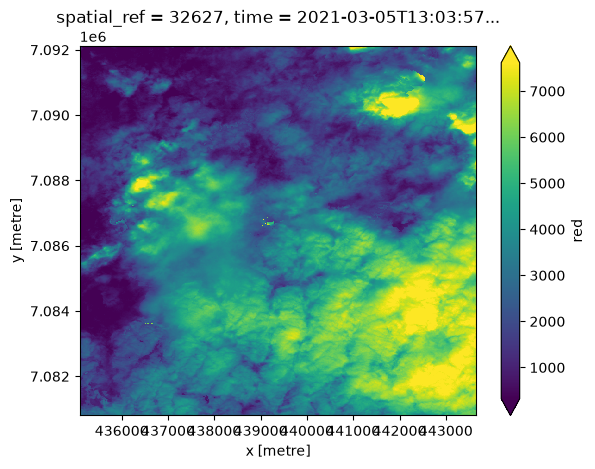

In [6]:
cube.red.isel(time=0).plot.imshow(robust=True)

### Per-pixel cloud masking with SCL
For general landcover this is good to do, but for our lava flow study, skip this part.

In [7]:
# keep vegetation, bare soil, water, unclassified
good = cube.scl.isin([4, 5, 6, 7])

masked = cube[["red", "green", "blue", "nir", "swir16", "swir22"]].where(good)

### Write the cube to Zarr

Before loading the Zarr, start a Dask client to get the dashboard and parallel downloads. Open the link, before continuing.

In [8]:
client = Client() 
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 7.86 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55662,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:55685,Total threads: 2
Dashboard: http://127.0.0.1:55690/status,Memory: 1.96 GiB
Nanny: tcp://127.0.0.1:55665,


2026-07-03 18:16:23,191 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1806s; attempting restart: <WorkerState 'tcp://127.0.0.1:55684', name: 3, status: running, memory: 0, processing: 0>
2026-07-03 18:16:24,496 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1806s; attempting restart: <WorkerState 'tcp://127.0.0.1:55685', name: 0, status: running, memory: 0, processing: 0>
2026-07-03 18:16:24,623 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1806s; attempting restart: <WorkerState 'tcp://127.0.0.1:55686', name: 1, status: running, memory: 0, processing: 0>
2026-07-03 18:16:24,753 - distributed.scheduler - WARNING - Worker failed to heartbeat for 1806s; attempting restart: <WorkerState 'tcp://127.0.0.1:55687', name: 2, status: running, memory: 0, processing: 0>
2026-07-03 21:27:51,812 - distributed.scheduler - WARNING - Worker failed to heartbeat for 10876s; attempting restart: <WorkerState 'tcp://127.0.0.1:49569', name: 2, st

In [9]:
cube.to_zarr("fagra_2021_2023.zarr", mode="w")

C:\Users\JULIA-PC\miniconda3\envs\eocube\Lib\site-packages\zarr\api\asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
